# Verde River Model Selection and Hyperparameter Tuning

In [19]:
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from Baselines.baselines import NaiveBaseline, SeasonalAverage, SeasonalRandomWalk
from sklearn.metrics import root_mean_squared_error
import itertools
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
season_length = 12
test_size = int(8.5 * season_length) # Set aside the last 8.5 years as our ultimate testing set.
df_train = df[:-test_size]
df_test = df[-test_size:]

## Verde River Downstream

Selecting most important lags.

In [ ]:
# ==========================================
# 1. FEATURE & DOWNSTREAM LAG CONFIGURATION
# ==========================================
verde_core_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream"
]

verde_lags = [
    "log_flow_verde_downstream_lag_1",
    "log_flow_verde_downstream_lag_2",
    "log_flow_verde_downstream_lag_3",
    "log_flow_verde_downstream_lag_4",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6",
    "log_flow_verde_downstream_lag_7",
    "log_flow_verde_downstream_lag_8",
    "log_flow_verde_downstream_lag_9",
    "log_flow_verde_downstream_lag_10",
    "log_flow_verde_downstream_lag_11",
    "log_flow_verde_downstream_lag_12"
]

models = {
    "randforest": RandomForestRegressor(n_jobs=-1, random_state=123),
    "adaboost": AdaBoostRegressor(random_state=123),
    "gradientboost": GradientBoostingRegressor(random_state=123),
    "xgboost": XGBRegressor(n_jobs=-1, random_state=123),
}

# ==========================================
# 2. DATA PREPARATION & FILE INITIALIZATION
# ==========================================
target = "log_flow_verde_downstream"
all_cols_needed = verde_core_features + verde_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)
n_lags_to_discover = 2
season_length = 12


output_filename = f"verde_downstream_lag_selection.txt"

with open(output_filename, "w") as f:
    f.write("=== VERDE RIVER DOWNSTREAM LAG SELECTION RESULTS ===\n")
    f.write(f"Target: {target}\n{'=' * 50}\n\n")

print("Selecting the best lags to complement the core features...\n")
print(f"Results are backing up in real-time to '{output_filename}'")

# ==========================================
# 3. FORWARD SELECTION COMPUTATION
# ==========================================
for name, model in models.items():
    print(f"Running lag selection optimization for: {name}...")
    current_features = verde_core_features.copy()
    remaining_lags = verde_lags.copy()
    lags_to_use = []

    best_step_baseline_rmses = []

    for step in range(n_lags_to_discover):
        best_score = float("inf")
        best_lag = None
        for lag in remaining_lags:
            features = current_features + [lag]
            rmses = []
            current_loop_baseline_rmses = []
            for train_index, test_index in tscv.split(df_model_train):
                X_tt = df_model_train[features].iloc[train_index]
                y_tt = df_model_train[target].iloc[train_index]

                model.fit(X_tt, y_tt)

                df_model_train_ho = (
                    df_model_train.iloc[test_index]
                    .copy()
                    .reset_index(drop=True)
                )
                y_ho = df_model_train_ho[target]
                preds = np.empty(len(df_model_train_ho))

                for month in range(len(df_model_train_ho)):
                    for lag_idx in range(1, 13):
                        if month >= lag_idx:
                            lag_col_name = (
                                f"log_flow_verde_downstream_lag_{lag_idx}"
                            )
                            df_model_train_ho.loc[month, lag_col_name] = preds[
                                month - lag_idx
                            ]
                    X_timestep = df_model_train_ho[features].iloc[[month]]
                    preds[month] = model.predict(X_timestep)[0]

                rmse = root_mean_squared_error(y_ho, preds)
                rmses.append(rmse)

                # Compute Seasonal Average baseline for this exact fold slice
                ts_tt_baseline = df_model_train[target].iloc[train_index]
                sa = SeasonalAverage(season_length=season_length)
                sa.fit(ts_tt_baseline)
                
                sa_preds = sa.forecast(len(test_index)) 
                baseline_rmse = root_mean_squared_error(y_ho, sa_preds)
                current_loop_baseline_rmses.append(baseline_rmse)

            score = np.mean(rmses)
            if score < best_score:
                best_score = score
                best_lag = lag
                best_step_baseline_rmses = current_loop_baseline_rmses

        current_features.append(best_lag)
        lags_to_use.append(best_lag)
        remaining_lags.remove(best_lag)

    baseline_overall_score = np.mean(best_step_baseline_rmses)

    # Log immediately to file
    with open(output_filename, "a") as f:
        f.write(f"Model Architecture: {name}\n")
        f.write(f"Top {n_lags_to_discover} Selected Lags: {lags_to_use}\n")
        f.write(f"Best Selection Validation RMSE: {best_score:.4f}\n")
        f.write(f"Benchmark Seasonal Average Baseline RMSE: {baseline_overall_score:.4f}\n")
        f.write(f"{'-' * 50}\n")

    print(f"Best Parameters found for {name} feature set: {lags_to_use}")
    print(f"Best Validation RMSE for {name} is {abs(best_score):.4f}")
    print(f"Benchmark Seasonal Average Baseline RMSE is {baseline_overall_score:.4f}")
    print(f"**{'-' * 70}**")

print(f"\nAll models processed successfully! Results saved in '{output_filename}'")

The Verde downstream flow lag selection results can be found in [verde_downstream_lag_selection.txt](verde_downstream_lag_selection.txt).

Next we do hyperparameter tuning for each model, with the best lags.

In [ ]:
# ==========================================
# 1. FEATURE & SPECIFIC MODEL LAG POOLS
# ==========================================
verde_core_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream"
]

verde_lags = [
    "log_flow_verde_downstream_lag_1",
    "log_flow_verde_downstream_lag_2",
    "log_flow_verde_downstream_lag_3",
    "log_flow_verde_downstream_lag_4",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6",
    "log_flow_verde_downstream_lag_7",
    "log_flow_verde_downstream_lag_8",
    "log_flow_verde_downstream_lag_9",
    "log_flow_verde_downstream_lag_10",
    "log_flow_verde_downstream_lag_11",
    "log_flow_verde_downstream_lag_12"
]

rf_lags = ['log_flow_verde_downstream_lag_4', 'log_flow_verde_downstream_lag_12']
ada_lags = ['log_flow_verde_downstream_lag_6', 'log_flow_verde_downstream_lag_1']
gradient_lags = ['log_flow_verde_downstream_lag_4', 'log_flow_verde_downstream_lag_2']
xg_lags = ['log_flow_verde_downstream_lag_6', 'log_flow_verde_downstream_lag_5']

unique_lags = list(set().union(rf_lags, ada_lags, gradient_lags, xg_lags))

models = {
    "randforest": {
        "model": RandomForestRegressor,
        "lags": rf_lags,
        "static_params": {"random_state": 123, "n_jobs": -1},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
    "adaboost": {
        "model": AdaBoostRegressor,
        "lags": ada_lags,
        "static_params": {"random_state": 123},
        "grid": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1]},
    },
    "gradientboost": {
        "model": GradientBoostingRegressor,
        "lags": gradient_lags,
        "static_params": {"random_state": 123},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
    "xgboost": {
        "model": XGBRegressor,
        "lags": xg_lags,
        "static_params": {"random_state": 42, "n_jobs": -1},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
}

# ==========================================
# 2. DATA PREPARATION & LOG INITIALIZATION
# ==========================================
target = "log_flow_verde_downstream"
all_cols_needed = verde_core_features + verde_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

ts_cv = TimeSeriesSplit(n_splits=5)
season_length = 12

# Generate filename for this execution run
output_filename = f"verde_downstream_grid_search_summary.txt"

# Open in write mode once at the top to instantiate the file header
with open(output_filename, "w") as f:
    f.write("=== VERDE DOWNSTREAM GRID SEARCH RESULTS ===\n")
    f.write(f"{'=' * 60}\n\n")

print(f"Grid search optimized. Exporting summary updates to: '{output_filename}'\n")

# ==========================================
# 3. TUNING AND HYPERPARAMETER OPTIMIZATION
# ==========================================
for name, info in models.items():
    print(f"Running grid search optimization for: {name}...")
    lags = info["lags"]

    grid_keys = list(info["grid"].keys())
    grid_values = list(info["grid"].values())
    combinations = [
        dict(zip(grid_keys, v)) for v in itertools.product(*grid_values)
    ]

    features = verde_core_features + lags

    best_score = float("inf")
    best_params = None
    best_step_baseline_rmses = []

    for combination in combinations:
        model = info["model"](**{**info["static_params"], **combination})
        rmses = []
        current_loop_baseline_rmses = []


        for train_index, test_index in ts_cv.split(df_model_train):
            X_tt = df_model_train[features].iloc[train_index]
            y_tt = df_model_train[target].iloc[train_index]

            model.fit(X_tt, y_tt)

            df_model_train_ho = (
                df_model_train.iloc[test_index].copy().reset_index(drop=True)
            )
            y_ho = df_model_train_ho[target]
            preds = np.empty(len(df_model_train_ho))

            # Month-by-month predictions
            for month in range(len(df_model_train_ho)):
                for lag_idx in range(1, 13):
                    if month >= lag_idx:
                        lag_col_name = f"log_flow_verde_downstream_lag_{lag_idx}"
                        df_model_train_ho.loc[month, lag_col_name] = preds[
                            month - lag_idx
                        ]

                X_timestep = df_model_train_ho[features].iloc[[month]]
                preds[month] = model.predict(X_timestep)[0]

            # Calculate rmse for this fold
            rmse = root_mean_squared_error(y_ho, preds)
            rmses.append(rmse)

            # Compute Seasonal Average baseline for this fold
            ts_tt_baseline = df_model_train[target].iloc[train_index]
            sa = SeasonalAverage(season_length=season_length)
            sa.fit(ts_tt_baseline)
                
            sa_preds = sa.forecast(len(test_index)) 
            baseline_rmse = root_mean_squared_error(y_ho, sa_preds)
            current_loop_baseline_rmses.append(baseline_rmse)

        score = np.mean(rmses)
        if score < best_score:
            best_score = score
            best_params = combination
            best_step_baseline_rmses = current_loop_baseline_rmses

    baseline_overall_score = np.mean(best_step_baseline_rmses)
    # Append parameters to our text log
    with open(output_filename, "a") as f:
        f.write(f"Model Architecture: {name}\n")
        f.write(f"Best Parameters Found: {best_params}\n")
        f.write(f"Best Recursive Cross-Validation RMSE: {abs(best_score):.4f}\n")
        f.write(f"Benchmark Seasonal Average Baseline RMSE: {baseline_overall_score:.4f}\n")
        f.write(f"{'-' * 70}\n")

    print(f"Best Parameters found for {name} are {best_params}")
    print(f"Best Validation RMSE for {name} is {abs(best_score):.4f}")
    print(f"Benchmark Seasonal Average Baseline RMSE is {baseline_overall_score:.4f}")
    print(f"**{'-' * 70}**")

print(f"\nAll operations complete! Results are stored inside your custom text file: '{output_filename}'")

The Verde downstream hyperparameter tuning results can be found in [verde_downstream_grid_search_summary.txt](verde_downstream_grid_search_summary.txt).

Now we fit the final model on the training data and look at feature importance.

In [3]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

verde_lags = [
    "log_flow_verde_downstream_lag_1",
    "log_flow_verde_downstream_lag_2",
    "log_flow_verde_downstream_lag_3",
    "log_flow_verde_downstream_lag_4",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6",
    "log_flow_verde_downstream_lag_7",
    "log_flow_verde_downstream_lag_8",
    "log_flow_verde_downstream_lag_9",
    "log_flow_verde_downstream_lag_10",
    "log_flow_verde_downstream_lag_11",
    "log_flow_verde_downstream_lag_12"
]

# ==========================================
# 2. DATA CLEANING & TARGET ISOLATION
# ==========================================
target = "log_flow_verde_downstream"
all_cols_needed = verde_downstream_features + verde_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

# ==========================================
# 3. MODEL INITIALIZATION & TRAINING
# ==========================================
verde_downstream_model = XGBRegressor(max_depth=6, n_estimators=100)

verde_downstream_model.fit(df_model_train[verde_downstream_features], df_model_train[target])

print("Model trained successfully on the historical data matrix!")
print()

# ==========================================
# 4. MODEL IMPORTANCES
# ==========================================

print("Model feature importances:")
model_importances = {v: float(verde_downstream_model.feature_importances_[i]) for (i,v) in enumerate(verde_downstream_features)}
sorted_model_importances = dict(sorted(model_importances.items(), key= lambda item: item[1], reverse=True))

sorted_model_importances

Model trained successfully on the historical data matrix!

Model feature importances:


{'log_flow_verde_upstream': 0.29463768005371094,
 'IrrigatedLand_Acres': 0.17727959156036377,
 'Population': 0.11378706246614456,
 'log_flow_verde_downstream_lag_5': 0.08568409830331802,
 'Precip_Maricopa': 0.07908855378627777,
 'Temp_Maricopa': 0.07833734154701233,
 'log_flow_verde_downstream_lag_6': 0.07410061359405518,
 'Precip_Verde': 0.050305310636758804,
 'Temp_Verde': 0.04618663713335991,
 'datacenters_TotalMW': 0.0005930206971243024,
 'datacenters_TotalNum': 0.0}

## Verde Upstream Flow

Finding most important lags.

In [ ]:
from datetime import datetime

# ==========================================
# 1. FEATURE & MODEL CONFIGURATION
# ==========================================
verde_upstream_core_features = [
    # Core Base Features
    "Temp_Verde",
    "Precip_Verde",
]

verde_upstream_lags = [
    # Verde Upstream lags
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_2",
    "log_flow_verde_upstream_lag_3",
    "log_flow_verde_upstream_lag_4",
    "log_flow_verde_upstream_lag_5",
    "log_flow_verde_upstream_lag_6",
    "log_flow_verde_upstream_lag_7",
    "log_flow_verde_upstream_lag_8",
    "log_flow_verde_upstream_lag_9",
    "log_flow_verde_upstream_lag_10",
    "log_flow_verde_upstream_lag_11",
    "log_flow_verde_upstream_lag_12",
]

models = {
    "randforest": RandomForestRegressor(n_jobs=-1, random_state=123),
    "adaboost": AdaBoostRegressor(random_state=123),
    "gradientboost": GradientBoostingRegressor(random_state=123),
    "xgboost": XGBRegressor(n_jobs=-1, random_state=123),
}

# ==========================================
# 2. DATA PREPARATION & LOG FILE INITIALIZATION
# ==========================================
all_cols_needed = (
    verde_upstream_core_features + verde_upstream_lags + ["log_flow_verde_upstream"]
)
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)
n_lags_to_discover = 2
season_length = 12
target = 'log_flow_verde_upstream'

# Create a filename for this selection run
output_filename = f"verde_upstream_lag_selection.txt"

with open(output_filename, "w") as f:
    f.write("=== VERDE RIVER UPSTREAM LAG SELECTION RESULTS ===\n")
    f.write(f"{'=' * 50}\n\n")

print(f"Selecting the best lags to complement the core features...")
print(f"Real-time backup logging to: '{output_filename}'\n")

# ==========================================
# 3. FORWARD SELECTION PROCESSING LOOP
# ==========================================
for name, model in models.items():
    print(f"Processing lag discovery iterations for model: {name}...")
    current_features = verde_upstream_core_features.copy()
    remaining_lags = verde_upstream_lags.copy()
    lags_to_use = []
    best_step_baseline_rmses = []

    for step in range(n_lags_to_discover):
        best_score = float("inf")
        best_lag = None
        
        for lag in remaining_lags:
            features = current_features + [lag]
            rmses = []
            current_loop_baseline_rmses = []

            
            for train_index, test_index in tscv.split(df_model_train):
                X_tt = df_model_train[features].iloc[train_index]
                y_tt = df_model_train["log_flow_verde_upstream"].iloc[train_index]

                model.fit(X_tt, y_tt)

                df_model_train_ho = (
                    df_model_train.iloc[test_index].copy().reset_index(drop=True)
                )
                y_ho = df_model_train_ho.log_flow_verde_upstream
                preds = np.empty(len(df_model_train_ho))

                for month in range(len(df_model_train_ho)):
                    for lag_idx in range(1, 13):
                        if month >= lag_idx:
                            lag_col_name = f"log_flow_verde_upstream_lag_{lag_idx}"
                            df_model_train_ho.loc[month, lag_col_name] = preds[
                                month - lag_idx
                            ]
                    X_timestep = df_model_train_ho[features].iloc[[month]]
                    preds[month] = model.predict(X_timestep)[0]

                rmse = root_mean_squared_error(y_ho, preds)
                rmses.append(rmse)

                # Compute Seasonal Average baseline for this fold
                ts_tt_baseline = df_model_train[target].iloc[train_index]
                sa = SeasonalAverage(season_length=season_length)
                sa.fit(ts_tt_baseline)
                
                sa_preds = sa.forecast(len(test_index)) 
                baseline_rmse = root_mean_squared_error(y_ho, sa_preds)
                current_loop_baseline_rmses.append(baseline_rmse)

            score = np.mean(rmses)
            if score < best_score:
                best_score = score
                best_lag = lag
                best_step_baseline_rmses = current_loop_baseline_rmses
                

        current_features.append(best_lag)
        lags_to_use.append(best_lag)
        remaining_lags.remove(best_lag)

    baseline_overall_score = np.mean(best_step_baseline_rmses)

    # Append parameters to our text log
    with open(output_filename, "a") as f:
        f.write(f"Model: {name}\n")
        f.write(f"Discovered Optimal Lags: {lags_to_use}\n")
        f.write(f"Best Average RMSE: {best_score:.4f}\n")
        f.write(f"Benchmark Seasonal Average Baseline RMSE: {baseline_overall_score:.4f}\n")
        f.write(f"{'-' * 50}\n")

    print(f"Best Parameters found for {name} feature set: {lags_to_use}")
    print(f"Best Validation RMSE for {name} is {abs(best_score):.4f}")
    print(f"Benchmark Seasonal Average Baseline RMSE is {baseline_overall_score:.4f}")
    print(f"**{'-' * 70}**")

print(f"\nOptimization cycle complete! Open '{output_filename}' to access your results.")

The Verde upstream lag selection results can be found in [verde_upstream_lag_selection.txt](verde_upstream_lag_selection.txt).

Now we do hyperparameter tuning for each model with the selected best lags.

In [ ]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_upstream_core_features = [
    "Temp_Verde",
    "Precip_Verde",
]

verde_upstream_lags = [
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_2",
    "log_flow_verde_upstream_lag_3",
    "log_flow_verde_upstream_lag_4",
    "log_flow_verde_upstream_lag_5",
    "log_flow_verde_upstream_lag_6",
    "log_flow_verde_upstream_lag_7",
    "log_flow_verde_upstream_lag_8",
    "log_flow_verde_upstream_lag_9",
    "log_flow_verde_upstream_lag_10",
    "log_flow_verde_upstream_lag_11",
    "log_flow_verde_upstream_lag_12"
]

rf_lags = ['log_flow_verde_upstream_lag_1', 'log_flow_verde_upstream_lag_7']
ada_lags = ['log_flow_verde_upstream_lag_2', 'log_flow_verde_upstream_lag_1']
gradient_lags = ['log_flow_verde_upstream_lag_1', 'log_flow_verde_upstream_lag_11']
xg_lags = ['log_flow_verde_upstream_lag_1', 'log_flow_verde_upstream_lag_4']

unique_lags = list(set().union(rf_lags, ada_lags, gradient_lags, xg_lags))

# ==========================================
# 2. MODEL TUNING CONFIGURATIONS
# ==========================================
models = {
    "randforest": {
        "model": RandomForestRegressor,
        "lags": rf_lags,
        "static_params": {"random_state": 123, "n_jobs": -1},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
    "adaboost": {
        "model": AdaBoostRegressor,
        "lags": ada_lags,
        "static_params": {"random_state": 123},
        "grid": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1]},
    },
    "gradientboost": {
        "model": GradientBoostingRegressor,
        "lags": gradient_lags,
        "static_params": {"random_state": 123},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
    "xgboost": {
        "model": XGBRegressor,
        "lags": xg_lags,
        "static_params": {"random_state": 42, "n_jobs": -1},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
}

# ==========================================
# 3. DATA PREPARATION & LOG INITIALIZATION
# ==========================================
target = "log_flow_verde_upstream"
all_cols_needed = verde_upstream_core_features + verde_upstream_lags + [target]

df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

ts_cv = TimeSeriesSplit(n_splits=5)
season_length = 12

# Generate a filename for this specific run
output_filename = f"verde_upstream_grid_search_summary.txt"

with open(output_filename, "w") as f:
    f.write("=== VERDE UPSTREAM GRID SEARCH RESULTS ===\n")
    f.write(f"{'=' * 60}\n\n")

print(f"Grid search started. Results will be saved to '{output_filename}'...\n")

# ==========================================
# 4. EXECUTION LOOP WITH FILE WRITING
# ==========================================
for name, info in models.items():
    print(f"Running grid search optimization for: {name}...")
    lags = info["lags"]

    grid_keys = list(info["grid"].keys())
    grid_values = list(info["grid"].values())
    combinations = [
        dict(zip(grid_keys, v)) for v in itertools.product(*grid_values)
    ]

    features = verde_upstream_core_features + lags

    best_score = float("inf")
    best_params = None
    best_step_baseline_rmses = []

    for combination in combinations:
        model = info["model"](**{**info["static_params"], **combination})
        rmses = []
        current_loop_baseline_rmses = []

        for train_index, test_index in ts_cv.split(df_model_train):
            X_tt = df_model_train[features].iloc[train_index]
            y_tt = df_model_train[target].iloc[train_index]

            model.fit(X_tt, y_tt)

            df_model_train_ho = (
                df_model_train.iloc[test_index].copy().reset_index(drop=True)
            )
            y_ho = df_model_train_ho[target]
            preds = np.empty(len(df_model_train_ho))

            # Month-by-month predictions
            for month in range(len(df_model_train_ho)):
                for lag_idx in range(1, 13):
                    if month >= lag_idx:
                        lag_col_name = f"log_flow_verde_upstream_lag_{lag_idx}"
                        df_model_train_ho.loc[month, lag_col_name] = preds[
                            month - lag_idx
                        ]

                X_timestep = df_model_train_ho[features].iloc[[month]]
                preds[month] = model.predict(X_timestep)[0]

            rmse = root_mean_squared_error(y_ho, preds)
            rmses.append(rmse)

            # Compute Seasonal Average baseline for this fold
            ts_tt_baseline = df_model_train[target].iloc[train_index]
            sa = SeasonalAverage(season_length=season_length)
            sa.fit(ts_tt_baseline)
                
            sa_preds = sa.forecast(len(test_index)) 
            baseline_rmse = root_mean_squared_error(y_ho, sa_preds)
            current_loop_baseline_rmses.append(baseline_rmse)

        score = np.mean(rmses)
        if score < best_score:
            best_score = score
            best_params = combination
            best_step_baseline_rmses = current_loop_baseline_rmses

    baseline_overall_score = np.mean(best_step_baseline_rmses)

    # Append results to our text log
    with open(output_filename, "a") as f:
        f.write(f"Model Architecture: {name}\n")
        f.write(f"Best Parameters Found: {best_params}\n")
        f.write(f"Best Recursive Cross-Validation RMSE: {abs(best_score):.4f}\n")
        f.write(f"Benchmark Seasonal Average Baseline RMSE: {baseline_overall_score:.4f}\n")
        f.write(f"{'-' * 70}\n")
        
    print(f"Best Parameters found for {name} are {best_params}")
    print(f"Best Validation RMSE for {name} is {abs(best_score):.4f}")
    print(f"Benchmark Seasonal Average Baseline RMSE is {baseline_overall_score:.4f}")
    print(f"**{'-' * 70}**")

print(f"\nAll models processed successfully! Open '{output_filename}' to view your results.")

The Verde upstream hyperparameter tuning results can be found in [verde_upstream_grid_search_summary.txt](verde_upstream_grid_search_summary.txt).

Now we fit the final model on the training data and look at feature importance.

In [14]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

verde_upstream_lags = [
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_2",
    "log_flow_verde_upstream_lag_3",
    "log_flow_verde_upstream_lag_4",
    "log_flow_verde_upstream_lag_5",
    "log_flow_verde_upstream_lag_6",
    "log_flow_verde_upstream_lag_7",
    "log_flow_verde_upstream_lag_8",
    "log_flow_verde_upstream_lag_9",
    "log_flow_verde_upstream_lag_10",
    "log_flow_verde_upstream_lag_11",
    "log_flow_verde_upstream_lag_12"
]

# ==========================================
# 2. DATA CLEANING & TARGET ISOLATION
# ==========================================
target = "log_flow_verde_upstream"
all_cols_needed = verde_upstream_features + verde_upstream_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

# ==========================================
# 3. MODEL INITIALIZATION & TRAINING
# ==========================================
verde_upstream_model = GradientBoostingRegressor(max_depth=3, n_estimators=100)

verde_upstream_model.fit(df_model_train[verde_upstream_features], df_model_train[target])

print("Model trained successfully on the historical data matrix!")
print()

# ==========================================
# 4. MODEL IMPORTANCES
# ==========================================

print("Model feature importances:")
model_importances = {v: float(verde_upstream_model.feature_importances_[i]) for (i,v) in enumerate(verde_upstream_features)}
sorted_model_importances = dict(sorted(model_importances.items(), key= lambda item: item[1], reverse=True))

sorted_model_importances

Model trained successfully on the historical data matrix!

Model feature importances:


{'log_flow_verde_upstream_lag_1': 0.3346245862971992,
 'Precip_Verde': 0.3286862958266212,
 'Temp_Verde': 0.30336853764446164,
 'log_flow_verde_upstream_lag_11': 0.03332058023171801}

# Future Water Flow Predictions

### SSP245 Climate Predictions

First we create a combined data file for making predictions.

In [35]:
# ==========================================
# 1. CREATING COMBINED DATA FILE
# ==========================================

# Load historical and future data sets
df_history = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
df_future = pd.read_csv("../Data/FormattedData/FutureVals_SSP245Climate_and_AllOtherFeatures.csv")

# Define the columns we want to keep from the historical data
extra_historical_targets = ["log_flow_verde_upstream","log_flow_verde_downstream"]
history_columns_to_keep = list(df_future.columns) + extra_historical_targets

# Extract the top 20 rows with the designated features
df_history_top20 = df_history.tail(20)[history_columns_to_keep].copy()

# Combine historical and pojected future data vertically
# Note: Pandas automatically pads the future rows with NaN under the target columns
df_combined_245 = pd.concat([df_history_top20, df_future], axis=0).reset_index(drop=True)

# Create lag columns
df_combined_245["log_flow_verde_upstream_lag_1"] = df_combined_245["log_flow_verde_upstream"].shift(1)
df_combined_245["log_flow_verde_upstream_lag_11"] = df_combined_245["log_flow_verde_upstream"].shift(11)
df_combined_245["log_flow_verde_downstream_lag_5"] = df_combined_245["log_flow_verde_downstream"].shift(5)
df_combined_245["log_flow_verde_downstream_lag_6"] = df_combined_245["log_flow_verde_downstream"].shift(6)

Now we use our upstream flow model to predict future values of Verde upstream water flow with SSP245 climate predictions.

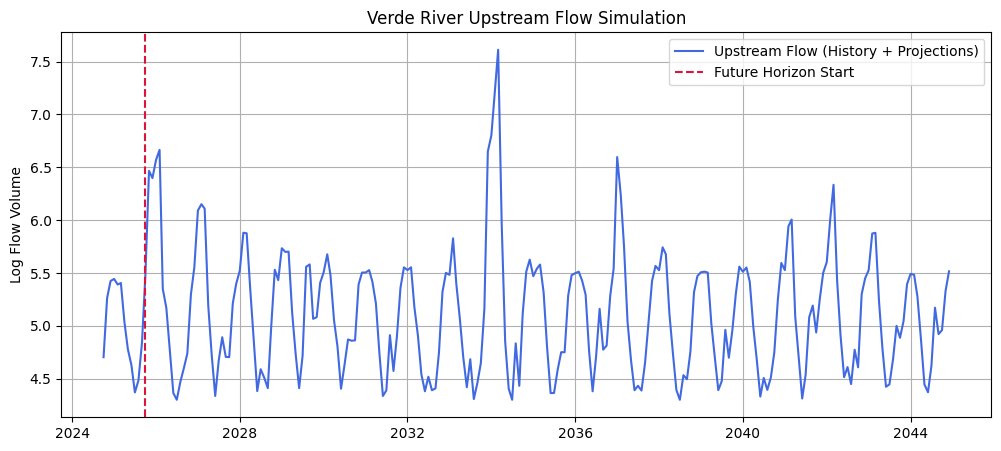

In [36]:
# ==========================================
# 1. CREATING FLOW PROJECTIONS
# ==========================================

verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

for i in range(12,len(df_combined_245.Time)):
    df_combined_245.loc[i,'log_flow_verde_upstream_lag_1'] = df_combined_245.loc[i-1,'log_flow_verde_upstream']
    df_combined_245.loc[i,'log_flow_verde_upstream_lag_11'] = df_combined_245.loc[i-11,'log_flow_verde_upstream']
    df_combined_245.loc[i,'log_flow_verde_upstream'] = verde_upstream_model.predict(df_combined_245[verde_upstream_features].iloc[[i]])[0]
    

# ==========================================
# 2. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_245["Time"]), 
    df_combined_245["log_flow_verde_upstream"], 
    label="Upstream Flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_245["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Verde River Upstream Flow Simulation")
plt.ylabel("Log Flow Volume")
plt.grid(True)
plt.legend()
plt.show()

Now we use our downstream model together with our Verde upstream flow predictions to predict future Verde downstream flow with SSP245 climate predictions.

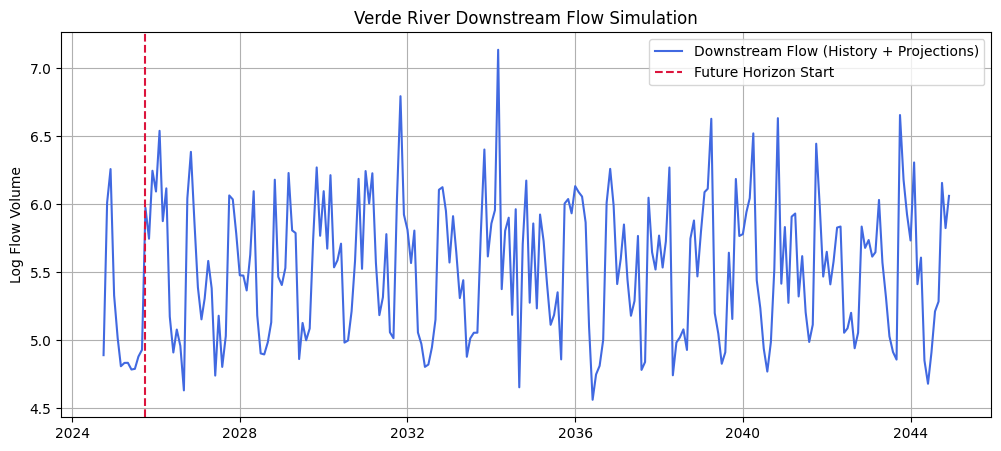

In [37]:
# ==========================================
# 1. CREATING FLOW PROJECTIONS
# ==========================================

verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

for i in range(12,len(df_combined_245.Time)):
    df_combined_245.loc[i,'log_flow_verde_downstream_lag_5'] = df_combined_245.loc[i-5,'log_flow_verde_downstream']
    df_combined_245.loc[i,'log_flow_verde_downstream_lag_6'] = df_combined_245.loc[i-6,'log_flow_verde_downstream']
    df_combined_245.loc[i,'log_flow_verde_downstream'] = verde_downstream_model.predict(df_combined_245[verde_downstream_features].iloc[[i]])[0]
    

# ==========================================
# 2. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_245["Time"]), 
    df_combined_245["log_flow_verde_downstream"], 
    label="Downstream Flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_245["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Verde River Downstream Flow Simulation")
plt.ylabel("Log Flow Volume")
plt.grid(True)
plt.legend()
plt.show()

### SSP585 Climate Predictions

First we create a combined data file for making predictions.

In [38]:
# ==========================================
# 1. CREATING COMBINED DATA FILE
# ==========================================

# Load historical and future data sets
df_history = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
df_future = pd.read_csv("../Data/FormattedData/FutureVals_SSP585Climate_and_AllOtherFeatures.csv")

# Define the columns we want to keep from the historical data
extra_historical_targets = ["log_flow_verde_upstream","log_flow_verde_downstream"]
history_columns_to_keep = list(df_future.columns) + extra_historical_targets

# Extract the top 20 rows with the designated features
df_history_top20 = df_history.tail(20)[history_columns_to_keep].copy()

# Combine historical and pojected future data vertically
# Note: Pandas automatically pads the future rows with NaN under the target columns
df_combined_585 = pd.concat([df_history_top20, df_future], axis=0).reset_index(drop=True)

# Create lag columns
df_combined_585["log_flow_verde_upstream_lag_1"] = df_combined_585["log_flow_verde_upstream"].shift(1)
df_combined_585["log_flow_verde_upstream_lag_11"] = df_combined_585["log_flow_verde_upstream"].shift(11)
df_combined_585["log_flow_verde_downstream_lag_5"] = df_combined_585["log_flow_verde_downstream"].shift(5)
df_combined_585["log_flow_verde_downstream_lag_6"] = df_combined_585["log_flow_verde_downstream"].shift(6)

First we use our upstream flow model to predict future values of Verde upstream water flow with SSP585 climate predictions.

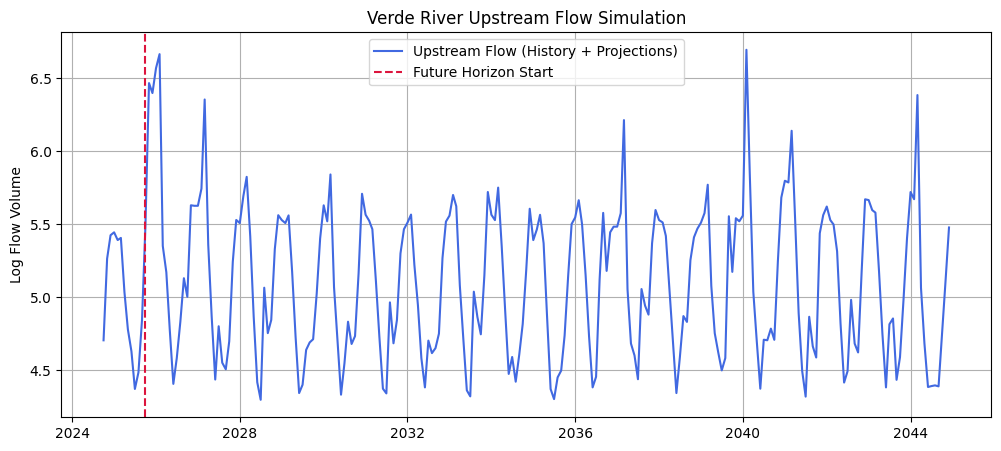

In [39]:
# ==========================================
# 1. CREATING FLOW PROJECTIONS
# ==========================================

verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

for i in range(12,len(df_combined_585.Time)):
    df_combined_585.loc[i,'log_flow_verde_upstream_lag_1'] = df_combined_585.loc[i-1,'log_flow_verde_upstream']
    df_combined_585.loc[i,'log_flow_verde_upstream_lag_11'] = df_combined_585.loc[i-11,'log_flow_verde_upstream']
    df_combined_585.loc[i,'log_flow_verde_upstream'] = verde_upstream_model.predict(df_combined_585[verde_upstream_features].iloc[[i]])[0]
    

# ==========================================
# 3. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["log_flow_verde_upstream"], 
    label="Upstream Flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_585["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Verde River Upstream Flow Simulation")
plt.ylabel("Log Flow Volume")
plt.grid(True)
plt.legend()
plt.show()

Now we use our downstream model together with our Verde upstream flow predictions to predict future Verde downstream flow with SSP585 climate predictions.

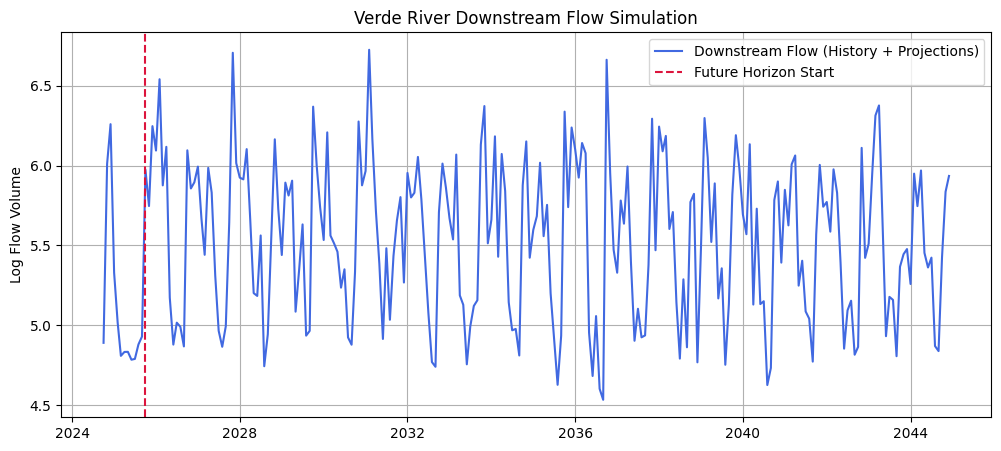

In [40]:
# ==========================================
# 1. CREATING FLOW PROJECTIONS
# ==========================================

verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

for i in range(12,len(df_combined_585.Time)):
    df_combined_585.loc[i,'log_flow_verde_downstream_lag_5'] = df_combined_585.loc[i-5,'log_flow_verde_downstream']
    df_combined_585.loc[i,'log_flow_verde_downstream_lag_6'] = df_combined_585.loc[i-6,'log_flow_verde_downstream']
    df_combined_585.loc[i,'log_flow_verde_downstream'] = verde_downstream_model.predict(df_combined_585[verde_downstream_features].iloc[[i]])[0]
    

# ==========================================
# 2. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["log_flow_verde_downstream"], 
    label="Downstream Flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_585["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Verde River Downstream Flow Simulation")
plt.ylabel("Log Flow Volume")
plt.grid(True)
plt.legend()
plt.show()

Now we plot the difference between the log upstream flow and the log downstream flow.

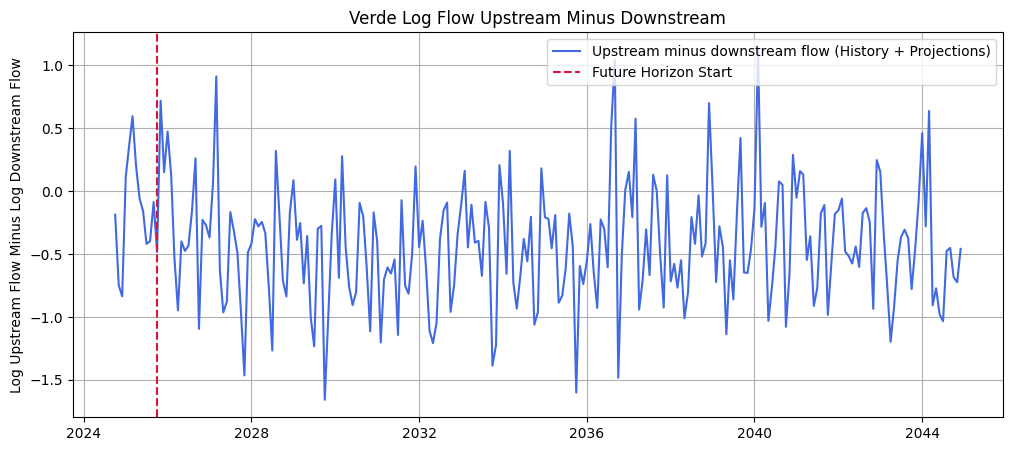

In [41]:
df_combined_585["difference_log_flow"] = df_combined_585["log_flow_verde_upstream"] - df_combined_585["log_flow_verde_downstream"]
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["difference_log_flow"], 
    label="Upstream minus downstream flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_585["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Verde Log Flow Upstream Minus Downstream")
plt.ylabel("Log Upstream Flow Minus Log Downstream Flow")
plt.grid(True)
plt.legend()
plt.show()

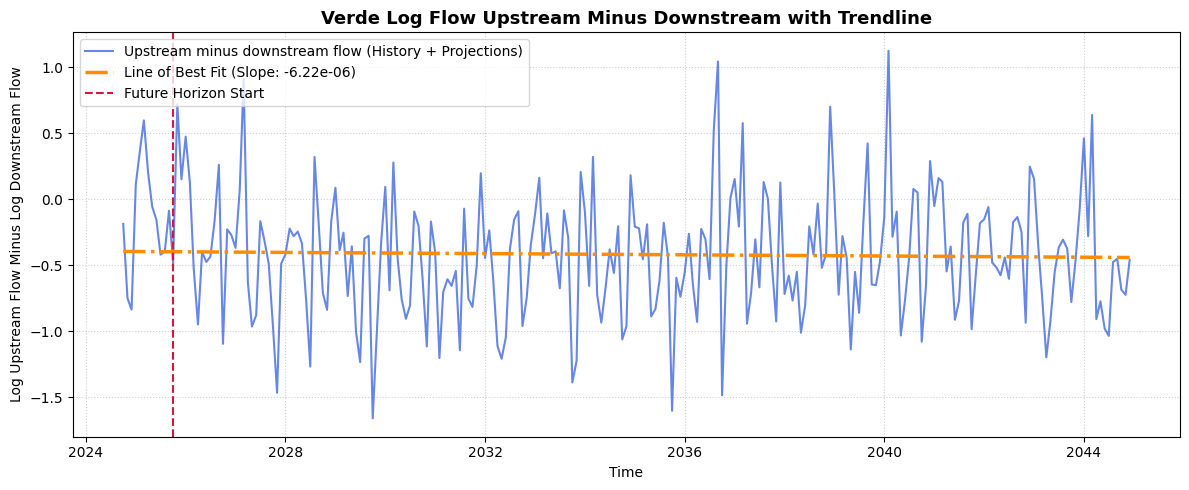

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate the difference metric
df_combined_585["difference_log_flow"] = df_combined_585["log_flow_verde_upstream"] - df_combined_585["log_flow_verde_downstream"]

# 2. Convert Dates to numerical ordinals for the best-fit math
dates_converted = pd.to_datetime(df_combined_585["Time"])
x_numerical = dates_converted.map(pd.Timestamp.toordinal)
y_values = df_combined_585["difference_log_flow"]

# 3. Calculate Linear Regression Line (Degree 1 polynomial)
# slope (m) and intercept (b) for y = mx + b
slope, intercept = np.polyfit(x_numerical, y_values, 1)
best_fit_line = slope * x_numerical + intercept

# ==========================================
# 4. PLOTTING THE OUTPUT WITH BEST FIT LINE
# ==========================================
plt.figure(figsize=(12, 5))

# Plot your original time series line
plt.plot(
    dates_converted, 
    y_values, 
    label="Upstream minus downstream flow (History + Projections)", 
    color="royalblue",
    alpha=0.8
)

# Plot the best fit line
plt.plot(
    dates_converted, 
    best_fit_line, 
    label=f"Line of Best Fit (Slope: {slope:.2e})", 
    color="darkorange", 
    linestyle="-.", 
    linewidth=2.5
)

# Safe vertical line marker using .values[12]
if len(df_combined_585) > 12:
    cutoff_date = pd.to_datetime(df_combined_585["Time"].values[12])
    plt.axvline(cutoff_date, color="crimson", linestyle="--", label="Future Horizon Start")

# Styling
plt.title("Verde Log Flow Upstream Minus Downstream with Trendline", fontsize=13, fontweight='bold')
plt.ylabel("Log Upstream Flow Minus Log Downstream Flow")
plt.xlabel("Time")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()